# 11.1 — Exposiciones: EE, EPE y PFE

Arranca M11 (XVAs). La **exposición** de un derivado en una fecha futura $t$ es
$\max(V_t,0)$ (no $V_t$): si la contraparte defaultea, sólo se pierde cuando el derivado
tiene valor positivo para nosotros. **EE(t)** $=E[\max(V_t,0)]$, **EPE** es el promedio
temporal de EE, **PFE** es un cuantil alto de $V_t$. Reusa exactamente la simulación de
tasas de 6.4 (Hull-White, $r_t=f(0,t)+\alpha(t)+x_t$) para revaluar un swap (y un
portafolio de 2 swaps) en cada fecha futura.

## 0. Configuración

Reutiliza (redefinido localmente) el marco de 6.4: curva Nelson-Siegel, Hull-White
($a=0.05,\sigma=0.01$), simulación exacta de $(x_t,\int_0^tx_sds)$ vía la solución OU.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

from qflib.market import nelson_siegel_df, par_swap_rate
from qflib.plotting import apply_style

apply_style()
rng = np.random.default_rng(42)

a, sigma = 0.05, 0.01

payment_times_A = np.arange(1.0, 6.0)  # swap A: 5Y
K_A = par_swap_rate(nelson_siegel_df, payment_times_A)
payment_times_B = np.arange(1.0, 4.0)  # swap B: 3Y, direccion opuesta (netting parcial)
K_B = par_swap_rate(nelson_siegel_df, payment_times_B)
print(f"swap A (5Y) par rate={K_A:.4%}, swap B (3Y) par rate={K_B:.4%}")

swap A (5Y) par rate=4.5008%, swap B (3Y) par rate=4.3596%


In [2]:
def instantaneous_forward(t, eps=1e-6):
    t = max(t, 1e-6)
    return (np.log(nelson_siegel_df(t - eps)) - np.log(nelson_siegel_df(t + eps))) / (2.0 * eps)


def hull_white_bond(t, T, r_t, a, sigma):
    B = (1.0 - np.exp(-a * (T - t))) / a
    f0t = instantaneous_forward(t)
    return ((nelson_siegel_df(T) / nelson_siegel_df(t))
            * np.exp(B * f0t - sigma ** 2 / (4 * a) * B ** 2 * (1.0 - np.exp(-2 * a * t)))
            * np.exp(-B * r_t))


def swap_value_remaining(t, r_t, K, all_payment_times, a, sigma):
    remaining = all_payment_times[all_payment_times > t + 1e-9]
    if len(remaining) == 0:
        return np.zeros_like(r_t)
    tau = np.diff(np.concatenate([[t], remaining]))
    dfs = np.array([hull_white_bond(t, Ti, r_t, a, sigma) for Ti in remaining])
    float_leg = 1.0 - dfs[-1]
    fixed_leg = K * np.sum(tau[:, None] * dfs, axis=0)
    return float_leg - fixed_leg


def ou_exact_joint(a, sigma, t, n_paths, rng):
    var_x = sigma ** 2 / (2 * a) * (1.0 - np.exp(-2 * a * t))
    var_I = sigma ** 2 / a ** 2 * (t - 2 / a * (1 - np.exp(-a * t)) + 1 / (2 * a) * (1 - np.exp(-2 * a * t)))
    cov_xI = sigma ** 2 / (2 * a ** 2) * (1.0 - np.exp(-a * t)) ** 2
    cov = np.array([[var_x, cov_xI], [cov_xI, var_I]])
    L = np.linalg.cholesky(cov)
    Z = rng.standard_normal((n_paths, 2))
    s = Z @ L.T
    return s[:, 0], s[:, 1]


def simulate_short_rate(t, a, sigma, n_paths, rng):
    x_t, _ = ou_exact_joint(a, sigma, t, n_paths, rng)
    alpha_t = sigma ** 2 / (2 * a ** 2) * (1.0 - np.exp(-a * t)) ** 2
    return instantaneous_forward(t) + alpha_t + x_t

## 1. Perfil EE / EPE / PFE de un swap único

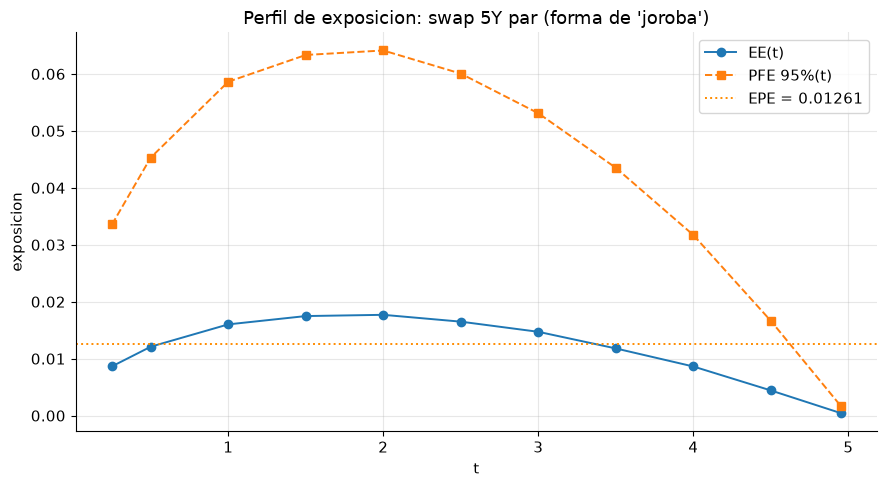

EE(t) >= 0 en toda la malla: True
EPE (promedio temporal de EE): 0.012607


In [3]:
n_paths = 100_000
check_times = np.concatenate([[0.25], np.arange(0.5, 5.0, 0.5), [4.95]])

# una sola simulacion por fecha, reutilizada para EE_A, PFE95_A, EE_B y EE_net --
# la desigualdad de netting es PUNTUAL por trayectoria (max(a-b,0)<=max(a,0)+max(b,0)),
# asi que exige comparar cantidades estimadas de las MISMAS trayectorias, no de corridas MC independientes.
EE_A, PFE95_A, EE_B, EE_net = [], [], [], []
for t in check_times:
    r_t = simulate_short_rate(t, a, sigma, n_paths, rng)
    V_A = swap_value_remaining(t, r_t, K_A, payment_times_A, a, sigma)
    V_B = swap_value_remaining(t, r_t, K_B, payment_times_B, a, sigma)
    V_portfolio = V_A - V_B  # swap B en direccion opuesta, mismo netting set
    EE_A.append(np.maximum(V_A, 0.0).mean())
    PFE95_A.append(np.quantile(V_A, 0.95))
    EE_B.append(np.maximum(-V_B, 0.0).mean())
    EE_net.append(np.maximum(V_portfolio, 0.0).mean())
EE_A, PFE95_A = np.array(EE_A), np.array(PFE95_A)
EE_B, EE_net = np.array(EE_B), np.array(EE_net)

# EPE: promedio temporal de EE(t) (regla del trapecio sobre la malla de check_times)
EPE_A = np.trapezoid(EE_A, check_times) / (check_times[-1] - check_times[0])

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(check_times, EE_A, "o-", label="EE(t)")
ax.plot(check_times, PFE95_A, "s--", label="PFE 95%(t)")
ax.axhline(EPE_A, color="darkorange", ls=":", label=f"EPE = {EPE_A:.5f}")
ax.set_xlabel("t"); ax.set_ylabel("exposicion")
ax.set_title("Perfil de exposicion: swap 5Y par (forma de 'joroba')")
ax.legend(); fig.tight_layout(); plt.show()

print(f"EE(t) >= 0 en toda la malla: {np.all(EE_A >= 0.0)}")
print(f"EPE (promedio temporal de EE): {EPE_A:.6f}")

## 2. Netting: portafolio de 2 swaps con signos opuestos

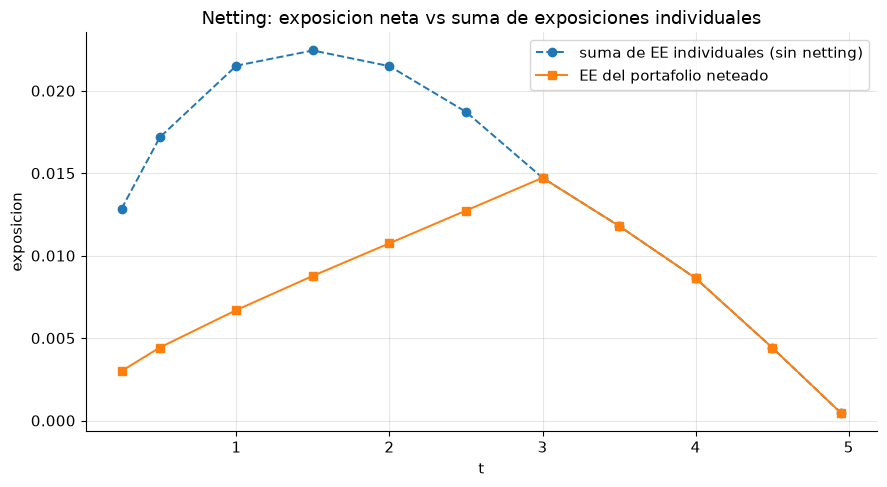

EE(neteado) <= EE_A + EE_B en toda la malla: True


In [4]:
fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(check_times, EE_A + EE_B, "o--", label="suma de EE individuales (sin netting)")
ax.plot(check_times, EE_net, "s-", label="EE del portafolio neteado")
ax.set_xlabel("t"); ax.set_ylabel("exposicion")
ax.set_title("Netting: exposicion neta vs suma de exposiciones individuales")
ax.legend(); fig.tight_layout(); plt.show()

netting_holds = np.all(EE_net <= EE_A + EE_B + 1e-9)
print(f"EE(neteado) <= EE_A + EE_B en toda la malla: {netting_holds}")

## 3. Validación

In [5]:
check1 = np.all(EE_A >= 0.0)
print(f"1. EE(t) >= 0 en toda la malla: {check1}")

check2 = abs(EPE_A - np.trapezoid(EE_A, check_times) / (check_times[-1] - check_times[0])) < 1e-12
print(f"2. EPE = promedio temporal de EE(t) por construccion: {check2}")

check3 = netting_holds
print(f"3. EE del portafolio neteado <= suma de EE individuales, en toda la malla: {check3}")

assert check1
assert check2
assert check3
print("\nValidacion completa: 3/3 dentro de tolerancia.")

1. EE(t) >= 0 en toda la malla: True
2. EPE = promedio temporal de EE(t) por construccion: True
3. EE del portafolio neteado <= suma de EE individuales, en toda la malla: True

Validacion completa: 3/3 dentro de tolerancia.


## Referencias

- Gregory, J. (2015). *The xVA Challenge*, cap. 3-4.
- Green, A. (2015). *XVA: Credit, Funding and Capital Valuation Adjustments*, cap. 4.